# Time-Varying Break-Even Growth Rate For E In Statsmodels

This notebook mirrors notebook 05, but uses employment growth `E` as the dependent variable instead of unemployment changes `U`.

The model is a `statsmodels` local-level specification with fixed GDP slopes and a time-varying intercept:

E_t = c_t + b_0 Y_t + b_1 Y_{t-1} + b_2 Y_{t-2} + g_2 D_{2020Q2,t} + g_3 D_{2020Q3,t} + eps_t

with

c_t = c_{t-1} + eta_t

The state innovation variance is constrained to `sigma2.level = (0.05 * sigma_ols)^2`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'time_varying_break_even_statsmodels_E.csv'

## Load Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date'])
analysis_df = analysis_df.sort_values('date').reset_index(drop=True)

state_df = analysis_df.loc[:, ['date', 'E', 'Y']].copy()
state_df['Y_lag1'] = state_df['Y'].shift(1)
state_df['Y_lag2'] = state_df['Y'].shift(2)
state_df['d2020q2'] = (state_df['date'] == pd.Timestamp('2020-04-01')).astype(float)
state_df['d2020q3'] = (state_df['date'] == pd.Timestamp('2020-07-01')).astype(float)
state_df = state_df.dropna().reset_index(drop=True)
state_df.head()

,date,E,Y,Y_lag1,Y_lag2,d2020q2,d2020q3
0,1992-07-01,-1.132308,-0.726074,-0.085709,0.570575,0.0,0.0
1,1992-10-01,-0.847614,-0.501668,-0.726074,-0.085709,0.0,0.0
2,1993-01-01,-0.839623,-0.332376,-0.501668,-0.726074,0.0,0.0
3,1993-04-01,0.812695,0.917484,-0.332376,-0.501668,0.0,0.0
4,1993-07-01,-0.310166,0.381316,0.917484,-0.332376,0.0,0.0


## Static OLS Benchmark

In [3]:
X_ols = sm.add_constant(state_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_result = sm.OLS(state_df['E'], X_ols).fit()
sigma_ols = float(ols_result.resid.std(ddof=int(ols_result.df_model) + 1))
std_eta_fixed = 0.05 * sigma_ols
sigma2_level_fixed = std_eta_fixed ** 2
sum_beta = float(ols_result.params['Y'] + ols_result.params['Y_lag1'] + ols_result.params['Y_lag2'])
static_break_even_qoq = -float(ols_result.params['const']) / sum_beta
static_break_even_annualized = ((1 + static_break_even_qoq / 100) ** 4 - 1) * 100

pd.DataFrame({
    'parameter': ['const', 'b0', 'b1', 'b2', 'g2', 'g3', 'sigma_ols', 'std_eta_fixed', 'static_break_even_qoq', 'static_break_even_annualized'],
    'estimate': [
        float(ols_result.params['const']),
        float(ols_result.params['Y']),
        float(ols_result.params['Y_lag1']),
        float(ols_result.params['Y_lag2']),
        float(ols_result.params['d2020q2']),
        float(ols_result.params['d2020q3']),
        sigma_ols,
        std_eta_fixed,
        static_break_even_qoq,
        static_break_even_annualized,
    ],
})

,parameter,estimate
0,const,0.044547
1,b0,0.216466
2,b1,0.139554
3,b2,0.048714
4,g2,-0.192471
5,g3,0.190188
6,sigma_ols,0.319763
7,std_eta_fixed,0.015988
8,static_break_even_qoq,-0.110066
9,static_break_even_annualized,-0.439538


## Statsmodels Local-Level Specification

As in notebook 05, we estimate a local-level model and constrain the state innovation variance to the OLS-based calibration.

In [4]:
exog = state_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']]

ucm = sm.tsa.UnobservedComponents(
    state_df['E'],
    level='local level',
    exog=exog,
)

start_params = ucm.start_params.copy()
param_names = list(ucm.param_names)
name_to_idx = {name: idx for idx, name in enumerate(param_names)}

for name, value in {
    'sigma2.level': sigma2_level_fixed,
    'beta.Y': float(ols_result.params['Y']),
    'beta.Y_lag1': float(ols_result.params['Y_lag1']),
    'beta.Y_lag2': float(ols_result.params['Y_lag2']),
    'beta.d2020q2': float(ols_result.params['d2020q2']),
    'beta.d2020q3': float(ols_result.params['d2020q3']),
}.items():
    if name in name_to_idx:
        start_params[name_to_idx[name]] = value

fixed_params = {'sigma2.level': sigma2_level_fixed}
with ucm.fix_params(fixed_params):
    ucm_result = ucm.fit(start_params=start_params, disp=False, includes_fixed=True)

print(ucm_result.summary())

                        Unobserved Components Results                         
Dep. Variable:                      E   No. Observations:                  134
Model:                    local level   Log Likelihood                 -29.295
Date:                Mon, 01 Jun 2026   AIC                             70.591
Time:                        09:59:31   BIC                             87.933
Sample:                             0   HQIC                            77.638
                                - 134                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
sigma2.irregular         0.0812      0.008     10.232      0.000       0.066       0.097
sigma2.level (fixed)     0.0003        nan        nan        nan         nan         nan
beta.Y      

In [5]:
param_table = pd.DataFrame({
    'parameter': ucm_result.param_names,
    'estimate': ucm_result.params,
})
param_table

,parameter,estimate
sigma2.irregular,sigma2.irregular,0.081248
sigma2.level,sigma2.level (fixed),0.000256
beta.Y,beta.Y,0.202438
beta.Y_lag1,beta.Y_lag1,0.119010
beta.Y_lag2,beta.Y_lag2,0.034752
beta.d2020q2,beta.d2020q2,-0.373659
beta.d2020q3,beta.d2020q3,0.059209


## Smoothed Level And Implied Break-Even Growth

In [6]:
smoothed_level = pd.Series(ucm_result.level.smoothed, index=state_df.index)

beta_cols = ['beta.Y', 'beta.Y_lag1', 'beta.Y_lag2']
sum_beta_ucm = float(sum(ucm_result.params[col] for col in beta_cols))

results_df = state_df.copy()
results_df['c_t'] = smoothed_level
results_df['break_even_growth_qoq_pct'] = -results_df['c_t'] / sum_beta_ucm
results_df['break_even_growth_annualized_pct'] = ((1 + results_df['break_even_growth_qoq_pct'] / 100) ** 4 - 1) * 100
results_df['static_break_even_qoq_pct'] = static_break_even_qoq
results_df['static_break_even_annualized_pct'] = static_break_even_annualized

results_df[['c_t', 'break_even_growth_qoq_pct', 'break_even_growth_annualized_pct']].describe().T

,count,mean,std,min,25%,50%,75%,max
c_t,134.0,0.068012,0.096211,-0.175220,0.032667,0.115359,0.137518,0.159900
break_even_growth_qoq_pct,134.0,-0.190939,0.270105,-0.448907,-0.386071,-0.323861,-0.091710,0.491914
break_even_growth_annualized_pct,134.0,-0.757234,1.079645,-1.783572,-1.535363,-1.289165,-0.366335,1.982221


## Employment Growth Scenarios

In [7]:
gdp_growth_2pct_annualized_qoq = ((1 + 0.02) ** 0.25 - 1) * 100

results_df['implied_E_if_gdp_0_qoq_pct'] = results_df['c_t']
results_df['implied_E_if_gdp_2pct_ann_qoq_pct'] = results_df['c_t'] + sum_beta_ucm * gdp_growth_2pct_annualized_qoq
results_df['implied_E_if_gdp_0_annualized_pct'] = ((1 + results_df['implied_E_if_gdp_0_qoq_pct'] / 100) ** 4 - 1) * 100
results_df['implied_E_if_gdp_2pct_ann_annualized_pct'] = ((1 + results_df['implied_E_if_gdp_2pct_ann_qoq_pct'] / 100) ** 4 - 1) * 100

pd.DataFrame({
    'scenario': ['GDP stagnation', 'GDP growth at 2% annualised'],
    'assumed_gdp_qoq_pct': [0.0, gdp_growth_2pct_annualized_qoq],
    'mean_implied_E_qoq_pct': [
        results_df['implied_E_if_gdp_0_qoq_pct'].mean(),
        results_df['implied_E_if_gdp_2pct_ann_qoq_pct'].mean(),
    ],
    'mean_implied_E_annualized_pct': [
        results_df['implied_E_if_gdp_0_annualized_pct'].mean(),
        results_df['implied_E_if_gdp_2pct_ann_annualized_pct'].mean(),
    ],
})

,scenario,assumed_gdp_qoq_pct,mean_implied_E_qoq_pct,mean_implied_E_annualized_pct
0,GDP stagnation,0.000000,0.068012,0.272879
1,GDP growth at 2% annualised,0.496293,0.244792,0.983323


## Plots

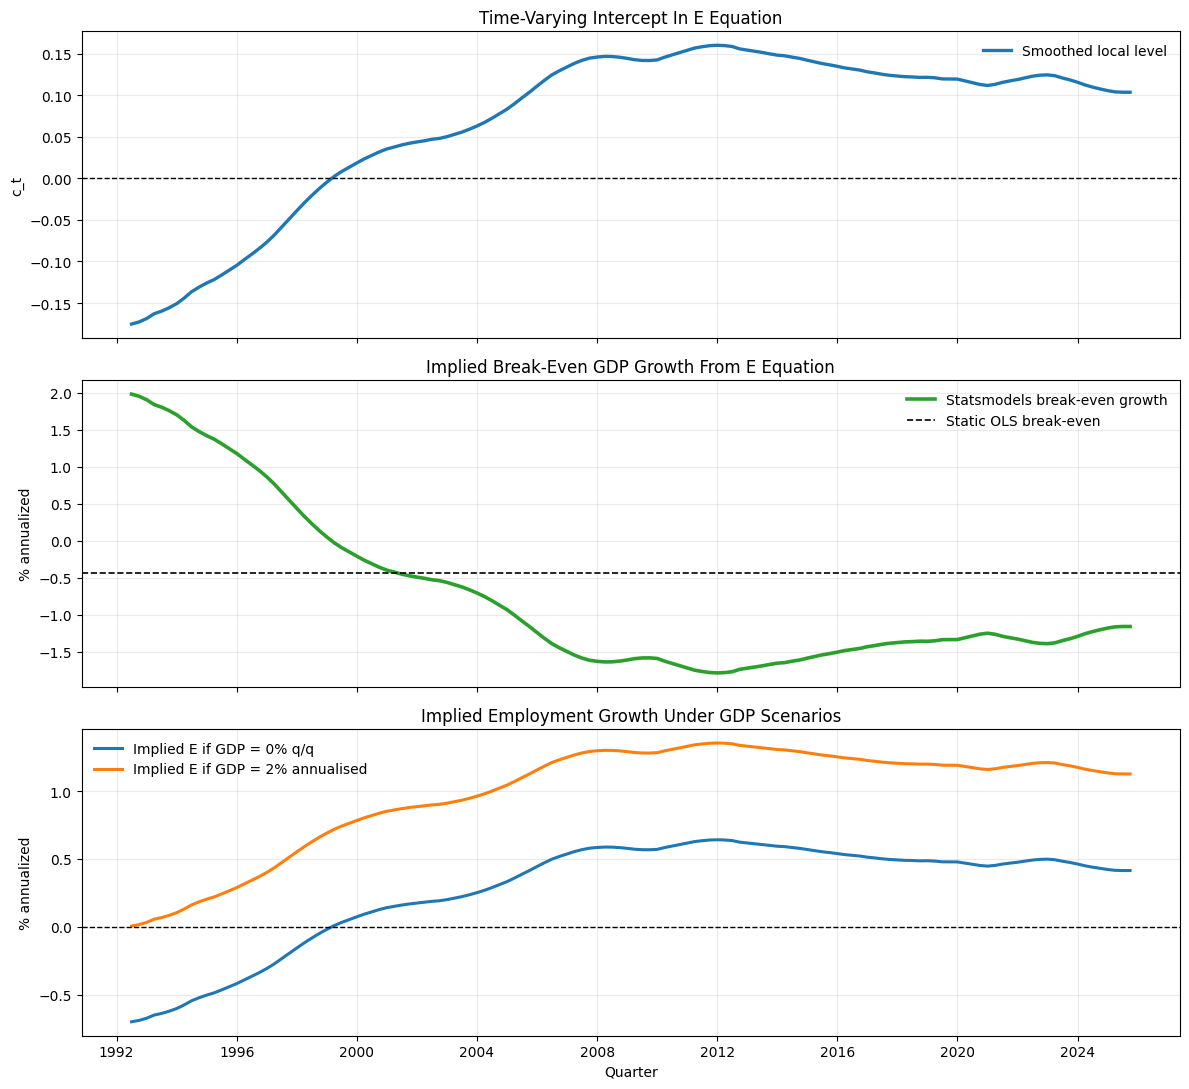

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
axes[0].plot(results_df['date'], results_df['c_t'], color='tab:blue', linewidth=2.4, label='Smoothed local level')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Time-Varying Intercept In E Equation')
axes[0].set_ylabel('c_t')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(results_df['date'], results_df['break_even_growth_annualized_pct'], color='tab:green', linewidth=2.6, label='Statsmodels break-even growth')
axes[1].axhline(static_break_even_annualized, color='black', linestyle='--', linewidth=1.2, label='Static OLS break-even')
axes[1].set_title('Implied Break-Even GDP Growth From E Equation')
axes[1].set_ylabel('% annualized')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

axes[2].plot(results_df['date'], results_df['implied_E_if_gdp_0_annualized_pct'], linewidth=2.2, label='Implied E if GDP = 0% q/q')
axes[2].plot(results_df['date'], results_df['implied_E_if_gdp_2pct_ann_annualized_pct'], linewidth=2.2, label='Implied E if GDP = 2% annualised')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.0)
axes[2].set_title('Implied Employment Growth Under GDP Scenarios')
axes[2].set_ylabel('% annualized')
axes[2].set_xlabel('Quarter')
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## Save Results

In [9]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/outputs/time_varying_break_even_statsmodels_E.csv')